In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

<h1># 1- Explore Data
</h1>

In [3]:
df=pd.read_excel('Book12.xlsx')

In [4]:
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge,MaritalStatus,ResidenceType
0,4751,73.0,0.0,0,2,22.927749,0.0,13.297218,6.327112,1.347214,...,1.725883,0.0,0,0,1,0,0,XXXConfid,0.0,1.0
1,4752,89.0,0.0,0,0,26.827681,0.0,4.542524,7.619885,0.518767,...,2.592424,0.0,0,0,0,1,0,XXXConfid,1.0,1.0
2,4753,73.0,0.0,3,1,17.795882,0.0,19.555085,7.844988,1.826335,...,7.119548,0.0,1,0,1,0,0,XXXConfid,2.0,1.0
3,4754,74.0,1.0,0,1,33.800817,1.0,12.209266,8.428001,7.435604,...,6.481226,0.0,0,0,0,0,0,XXXConfid,2.0,1.0
4,4755,89.0,1.0,0,0,20.716974,0.0,18.454356,6.310461,0.795498,...,0.014691,0.0,0,1,1,0,0,XXXConfid,2.0,1.0


In [5]:
df.shape

(2471, 37)

In [6]:
df.columns

Index(['PatientID', 'Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI',
       'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality',
       'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease',
       'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP',
       'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Diagnosis', 'DoctorInCharge', 'MaritalStatus',
       'ResidenceType'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2471 entries, 0 to 2470
Data columns (total 37 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2471 non-null   int64  
 1   Age                        2456 non-null   float64
 2   Gender                     2451 non-null   float64
 3   Ethnicity                  2471 non-null   int64  
 4   EducationLevel             2471 non-null   int64  
 5   BMI                        2425 non-null   float64
 6   Smoking                    2456 non-null   float64
 7   AlcoholConsumption         2471 non-null   float64
 8   PhysicalActivity           2471 non-null   float64
 9   DietQuality                2471 non-null   float64
 10  SleepQuality               2457 non-null   float64
 11  FamilyHistoryAlzheimers    2471 non-null   int64  
 12  CardiovascularDisease      2469 non-null   float64
 13  Diabetes                   2470 non-null   float

In [8]:
df.dtypes

PatientID                      int64
Age                          float64
Gender                       float64
Ethnicity                      int64
EducationLevel                 int64
BMI                          float64
Smoking                      float64
AlcoholConsumption           float64
PhysicalActivity             float64
DietQuality                  float64
SleepQuality                 float64
FamilyHistoryAlzheimers        int64
CardiovascularDisease        float64
Diabetes                     float64
Depression                     int64
HeadInjury                     int64
Hypertension                   int64
SystolicBP                     int64
DiastolicBP                  float64
CholesterolTotal             float64
CholesterolLDL               float64
CholesterolHDL               float64
CholesterolTriglycerides     float64
MMSE                         float64
FunctionalAssessment         float64
MemoryComplaints             float64
BehavioralProblems           float64
A

<h1>Clean Data</h1>

In [18]:
df.duplicated().sum()

322

In [20]:
df.drop_duplicates(inplace=True)


In [22]:
def count_duplicate_columns_by_content(df):
    return df.T.duplicated().sum()
count_duplicate_columns_by_content(df)

0

In [24]:
df.isna().sum()

PatientID                       0
Age                            15
Gender                         20
Ethnicity                       0
EducationLevel                  0
BMI                            46
Smoking                        15
AlcoholConsumption              0
PhysicalActivity                0
DietQuality                     0
SleepQuality                   14
FamilyHistoryAlzheimers         0
CardiovascularDisease           2
Diabetes                        1
Depression                      0
HeadInjury                      0
Hypertension                    0
SystolicBP                      0
DiastolicBP                     6
CholesterolTotal                1
CholesterolLDL                  5
CholesterolHDL                  0
CholesterolTriglycerides        0
MMSE                            1
FunctionalAssessment           12
MemoryComplaints                1
BehavioralProblems              1
ADL                             1
Confusion                       1
Disorientation

<h3>Age</h3>

In [27]:
average_age = df["Age"].mean()
average_age


74.86879100281162

In [29]:
df["Age"] = df["Age"].fillna(average_age)


In [31]:
negative_ages = df[df["Age"] < 0]
print(negative_ages)

    PatientID   Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
14       4765 -64.0     1.0          0               2  27.942863      0.0   

    AlcoholConsumption  PhysicalActivity  DietQuality  ...       ADL  \
14             2.17578          9.714566     5.317232  ...  5.505587   

    Confusion  Disorientation  PersonalityChanges  DifficultyCompletingTasks  \
14        1.0               1                   1                          0   

    Forgetfulness  Diagnosis  DoctorInCharge  MaritalStatus  ResidenceType  
14              0          0       XXXConfid            1.0            1.0  

[1 rows x 37 columns]


In [33]:
df["Age"] = df["Age"].apply(lambda x: average_age if pd.isnull(x) or x < 0 else x)

<h3>Gender</h3>

In [36]:
gender_counts = df["Gender"].value_counts()
print(gender_counts)

Gender
1.0    1075
0.0    1054
Name: count, dtype: int64


In [38]:

df["Gender"] = df["Gender"].bfill()

<h3>BMI</h3>

In [41]:
average_BMI = df["BMI"].mean()
average_BMI


27.67481318017594

In [43]:
df["BMI"] = df["BMI"].fillna(average_BMI)


<h3>Smoking</h3>

In [46]:
Smoking_counts = df["Smoking"].value_counts()
print(Smoking_counts)

Smoking
0.0    1517
1.0     617
Name: count, dtype: int64


In [48]:
df["Smoking"] = df["Smoking"].fillna(0)


<h3>SleepQuality</h3>

In [51]:
average_SleepQuality = df["SleepQuality"].mean()
average_SleepQuality


7.0518960701812645

In [53]:
df["SleepQuality"] = df["SleepQuality"].fillna(average_SleepQuality)


<h3>CardiovascularDisease</h3>

In [56]:
CardiovascularDisease_counts = df["CardiovascularDisease"].value_counts()
print(CardiovascularDisease_counts)

CardiovascularDisease
0.0    1837
1.0     310
Name: count, dtype: int64


In [58]:
df["CardiovascularDisease"] = df["CardiovascularDisease"].fillna(0)

<h3>Diabetes</h3>

In [61]:
Diabetes_counts = df["Diabetes"].value_counts()
print(Diabetes_counts)

Diabetes
0.0    1824
1.0     324
Name: count, dtype: int64


In [63]:
df["Diabetes"] = df["Diabetes"].fillna(0)

<h3>DiastolicBP </h3>

In [66]:
average_DiastolicBP = df["DiastolicBP"].mean()
average_DiastolicBP


89.8623425104993

In [68]:
df["DiastolicBP"] = df["DiastolicBP"].fillna(average_DiastolicBP)



<h3>CholesterolTotal</h3>

In [71]:

average_CholesterolTotal = df["CholesterolTotal"].mean()
average_CholesterolTotal


225.18078734878955

In [73]:
df["CholesterolTotal"] = df["CholesterolTotal"].fillna(average_CholesterolTotal)


<h3>CholesterolLDL</h3>

In [76]:
average_CholesterolLDL = df["CholesterolLDL"].mean()
average_CholesterolLDL

124.32408283596082

In [78]:
df["CholesterolLDL"] = df["CholesterolLDL"].fillna(average_CholesterolLDL)


<h3>MMSE</h3>

In [81]:
average_MMSE = df["MMSE"].mean()
average_MMSE

14.750557098606611

In [83]:
df["MMSE"] = df["MMSE"].fillna(average_MMSE)


<h3>FunctionalAssessment</h3>

In [129]:
average_FunctionalAssessment = df["FunctionalAssessment"].mean()
average_FunctionalAssessment

5.07868087295882

In [131]:
df["FunctionalAssessment"] = df["FunctionalAssessment"].fillna(average_FunctionalAssessment)



<h3>MemoryComplaints                </h3>

In [134]:
MemoryComplaints_counts = df["MemoryComplaints"].value_counts()
print(MemoryComplaints_counts)

MemoryComplaints
0.0    1701
1.0     447
Name: count, dtype: int64


In [136]:
df["MemoryComplaints"] = df["MemoryComplaints"].fillna(0)

<h3>BehavioralProblems</h3>

In [139]:
BehavioralProblems_counts = df["BehavioralProblems"].value_counts()
print(BehavioralProblems_counts)

BehavioralProblems
0.0    1812
1.0     336
Name: count, dtype: int64


In [141]:
df["BehavioralProblems"] = df["BehavioralProblems"].fillna(0)

<h3>ADL</h3>

In [144]:
average_ADL = df["ADL"].mean()
average_ADL

4.982835532356611

In [146]:
df["ADL"] = df["ADL"].fillna(average_MMSE)


<h3>Confusion</h3>

In [149]:
Confusion_counts = df["Confusion"].value_counts()
print(Confusion_counts)

Confusion
0.0    1707
1.0     441
Name: count, dtype: int64


In [151]:
df["Confusion"] = df["Confusion"].fillna(0)

<h3>MaritalStatus-ResidenceType</h3>

In [154]:
df.drop(columns=["MaritalStatus"], inplace=True)


In [156]:
df.drop(columns=["ResidenceType"], inplace=True)

<h3>Label Encoding of DoctorInCharge</h3>

In [159]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['DoctorInCharge'] = le.fit_transform(df['DoctorInCharge'])



In [161]:
df.isna().sum()

PatientID                    0
Age                          0
Gender                       0
Ethnicity                    0
EducationLevel               0
BMI                          0
Smoking                      0
AlcoholConsumption           0
PhysicalActivity             0
DietQuality                  0
SleepQuality                 0
FamilyHistoryAlzheimers      0
CardiovascularDisease        0
Diabetes                     0
Depression                   0
HeadInjury                   0
Hypertension                 0
SystolicBP                   0
DiastolicBP                  0
CholesterolTotal             0
CholesterolLDL               0
CholesterolHDL               0
CholesterolTriglycerides     0
MMSE                         0
FunctionalAssessment         0
MemoryComplaints             0
BehavioralProblems           0
ADL                          0
Confusion                    0
Disorientation               0
PersonalityChanges           0
DifficultyCompletingTasks    0
Forgetfu

<h3>Feature Scling</h3>

In [164]:
from sklearn.preprocessing import MinMaxScaler


<h1>02-Data Visualization </h1>

<h3>Correlation Heatmap of Numerical Features</h3>
<h5>+1 → Strong positive correlation</h5>
<h5>0 → No correlation</h5>
<h5>-1 → Strong negative correlation</h5>

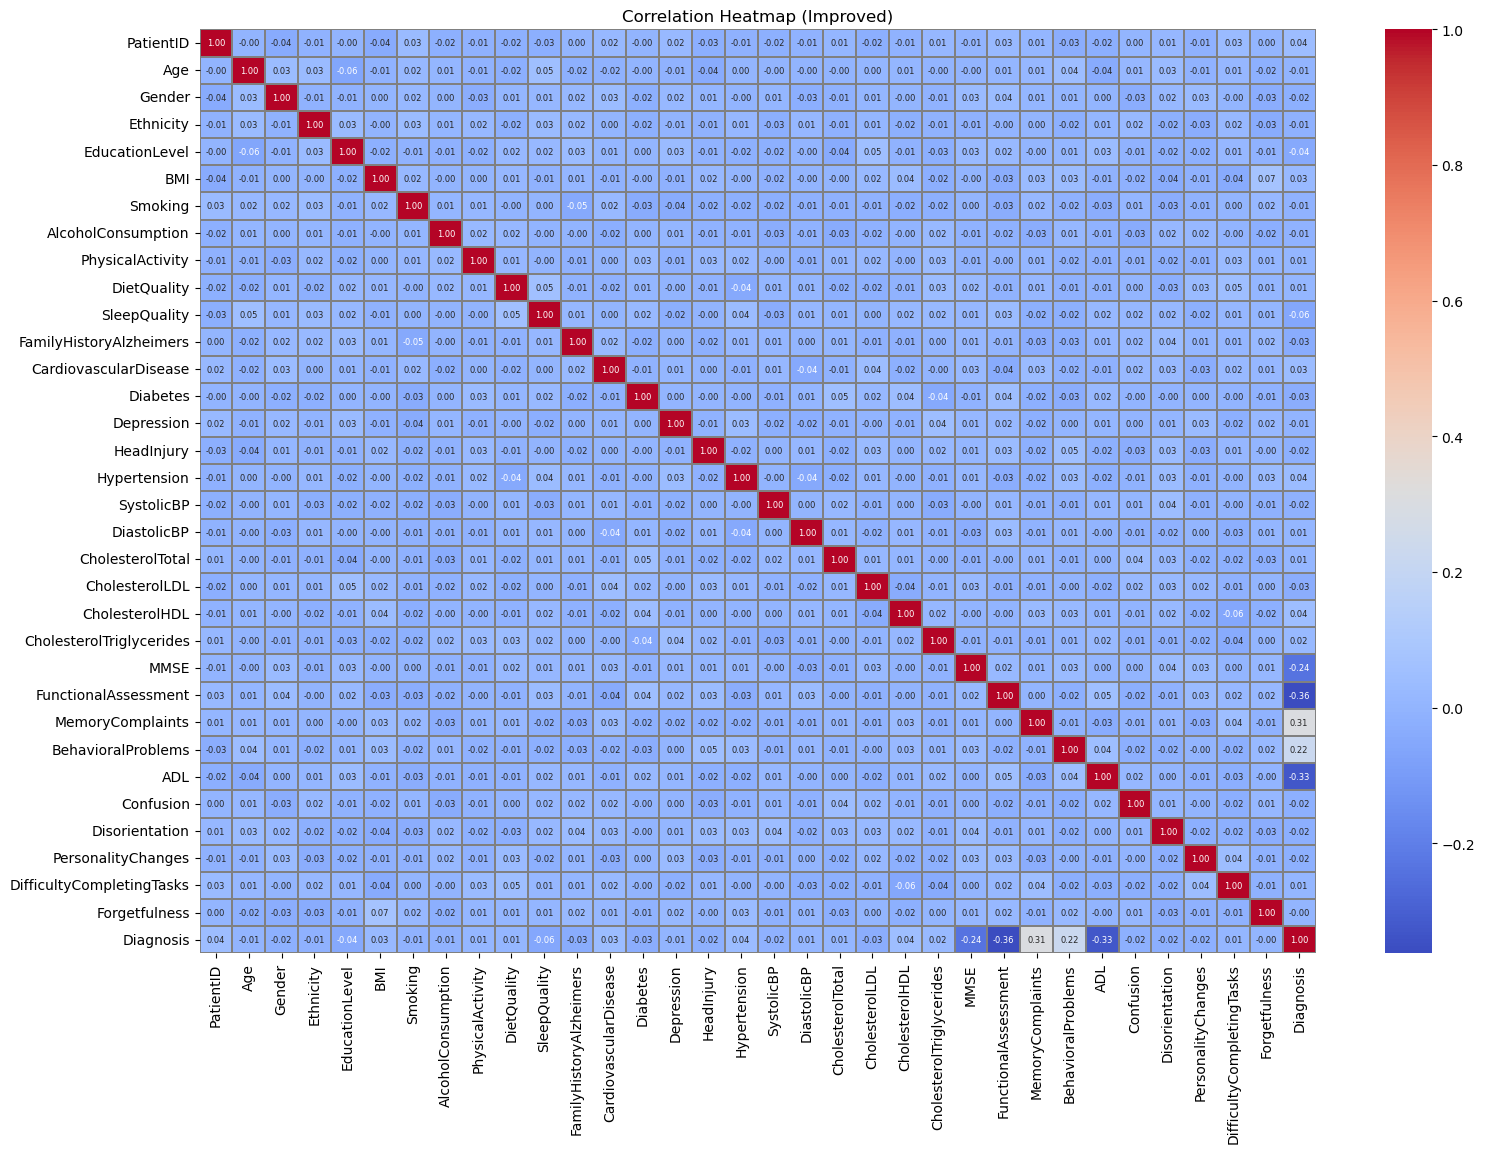

In [167]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
corr = df[num_cols].corr()

plt.figure(figsize=(18, 12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.3,
    linecolor="grey",
    cbar=True,
    annot_kws={"size": 6}
)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Correlation Heatmap (Improved)")
plt.show()



<h3>Age</h3>

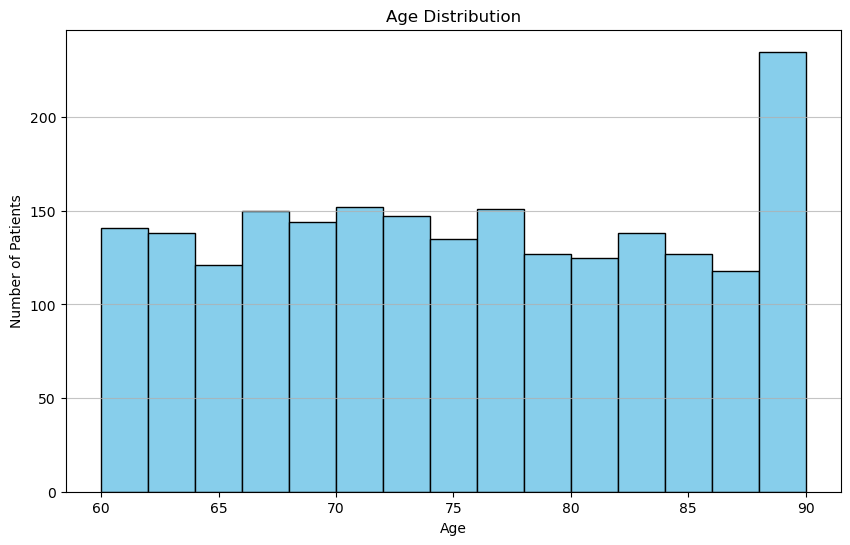

In [169]:
# رسم الهستوجرام لتوزيع الأعمار
plt.figure(figsize=(10,6))
plt.hist(df["Age"], bins=15, color='skyblue', edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.grid(axis='y', alpha=0.75)
plt.show()

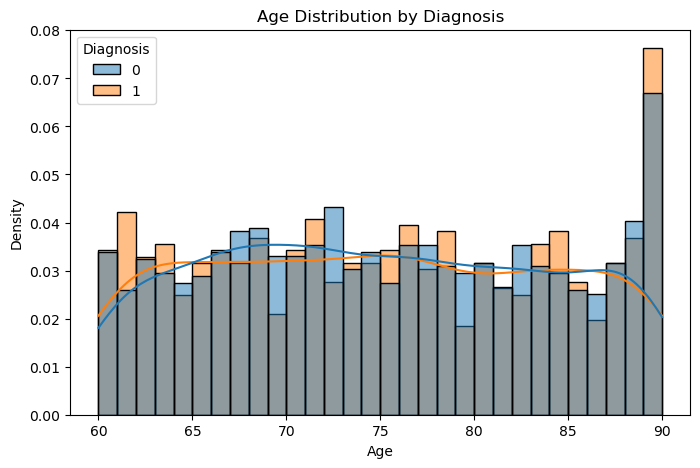

In [170]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", hue="Diagnosis", bins=30, kde=True, stat="density", common_norm=False)
plt.title("Age Distribution by Diagnosis")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

<h3>Gender vs Diagnosis</h3>

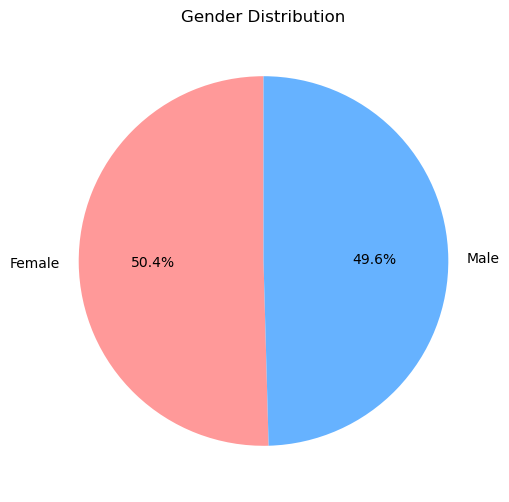

In [172]:
gender_counts = df["Gender"].value_counts()
gender_percentage = df["Gender"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,6))
plt.pie(
    gender_counts,
    labels=["Female", "Male"],
    autopct="%1.1f%%",   
    colors= ["#FF9999", "#66B2FF"],
    startangle=90
)
plt.title("Gender Distribution")
plt.show()

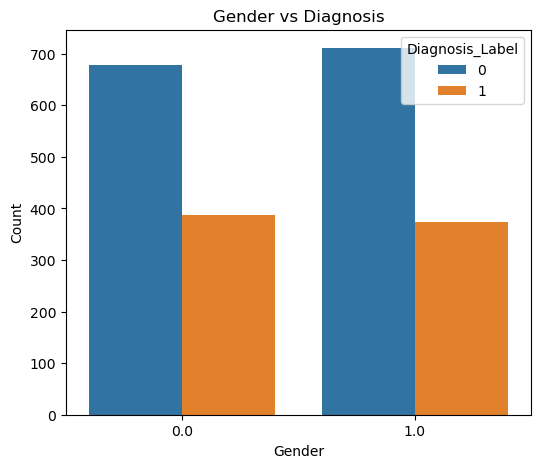

In [177]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="Gender", hue="Diagnosis")
plt.title("Gender vs Diagnosis")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Diagnosis_Label")
plt.show()

<h3>Smoking</h3>

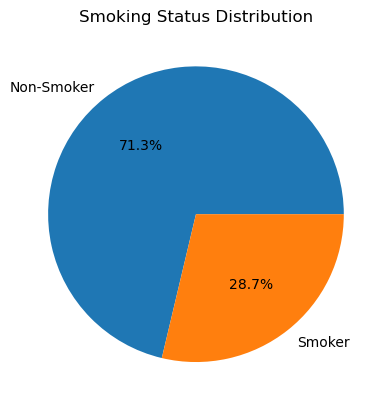

In [180]:
smoking_counts = df['Smoking'].value_counts()
plt.figure()
plt.pie(
    smoking_counts,
    labels=['Non-Smoker', 'Smoker'],
    autopct='%1.1f%%'
)
plt.title('Smoking Status Distribution')
plt.show()

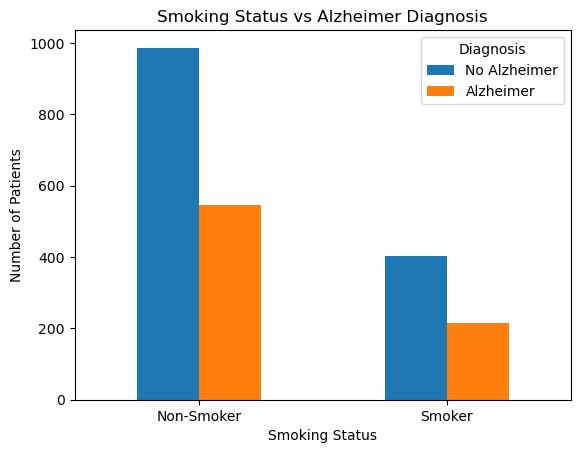

In [182]:
# Create a grouped count table
grouped = pd.crosstab(df['Smoking'], df['Diagnosis'])

# Rename rows and columns for clarity
grouped.index = ['Non-Smoker', 'Smoker']
grouped.columns = ['No Alzheimer', 'Alzheimer']

# Plot grouped bar chart
grouped.plot(kind='bar')

plt.title('Smoking Status vs Alzheimer Diagnosis')
plt.xlabel('Smoking Status')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.legend(title='Diagnosis')

plt.show()

<h3>Family History vs Diagnosis</h3>

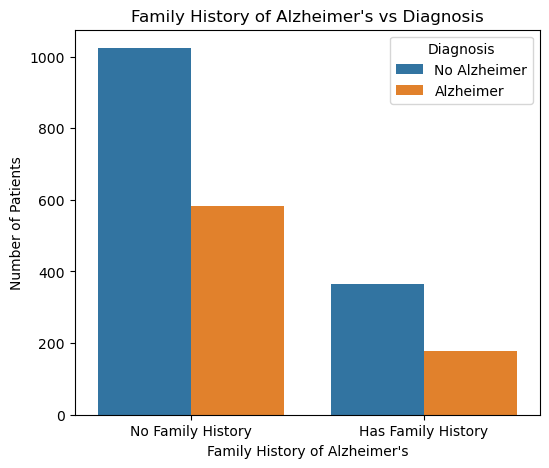

In [185]:
plt.figure(figsize=(6, 5))

sns.countplot(
    data=df,
    x="FamilyHistoryAlzheimers",
    hue="Diagnosis"
)
plt.title("Family History of Alzheimer's vs Diagnosis")
plt.xlabel("Family History of Alzheimer's")
plt.ylabel("Number of Patients")
plt.xticks(
    ticks=[0, 1],
    labels=["No Family History", "Has Family History"]
)
plt.legend(
    title="Diagnosis",
    labels=["No Alzheimer", "Alzheimer"]
)

plt.show()

<h3>MMSE Score VS Diagnosis</h3>

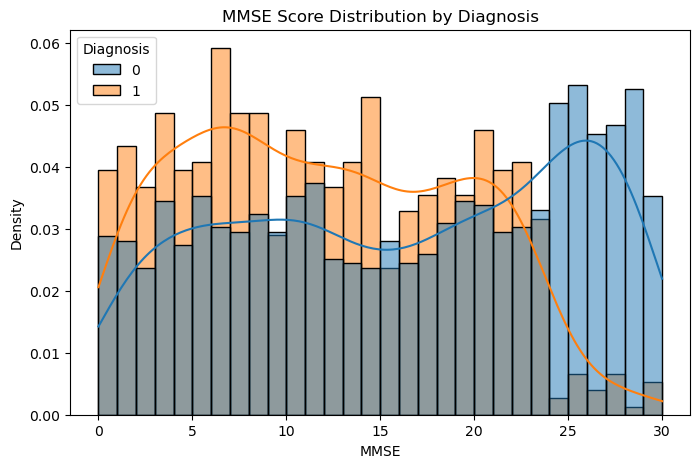

In [188]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="MMSE", hue="Diagnosis", bins=30, kde=True, stat="density", common_norm=False)
plt.title("MMSE Score Distribution by Diagnosis")
plt.xlabel("MMSE")
plt.ylabel("Density")
plt.show()

<h3>Alcohol Vs Diagnosis</h3>

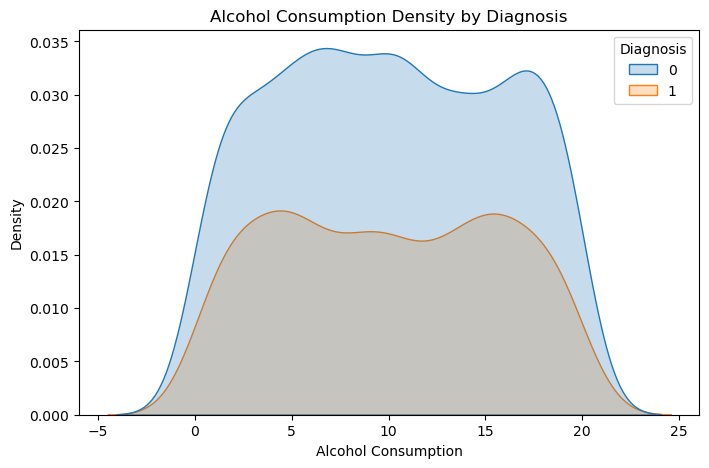

In [191]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x="AlcoholConsumption", hue="Diagnosis", fill=True)
plt.title("Alcohol Consumption Density by Diagnosis")
plt.xlabel("Alcohol Consumption")
plt.show()

<h3>Relationships of Key Features</h3>

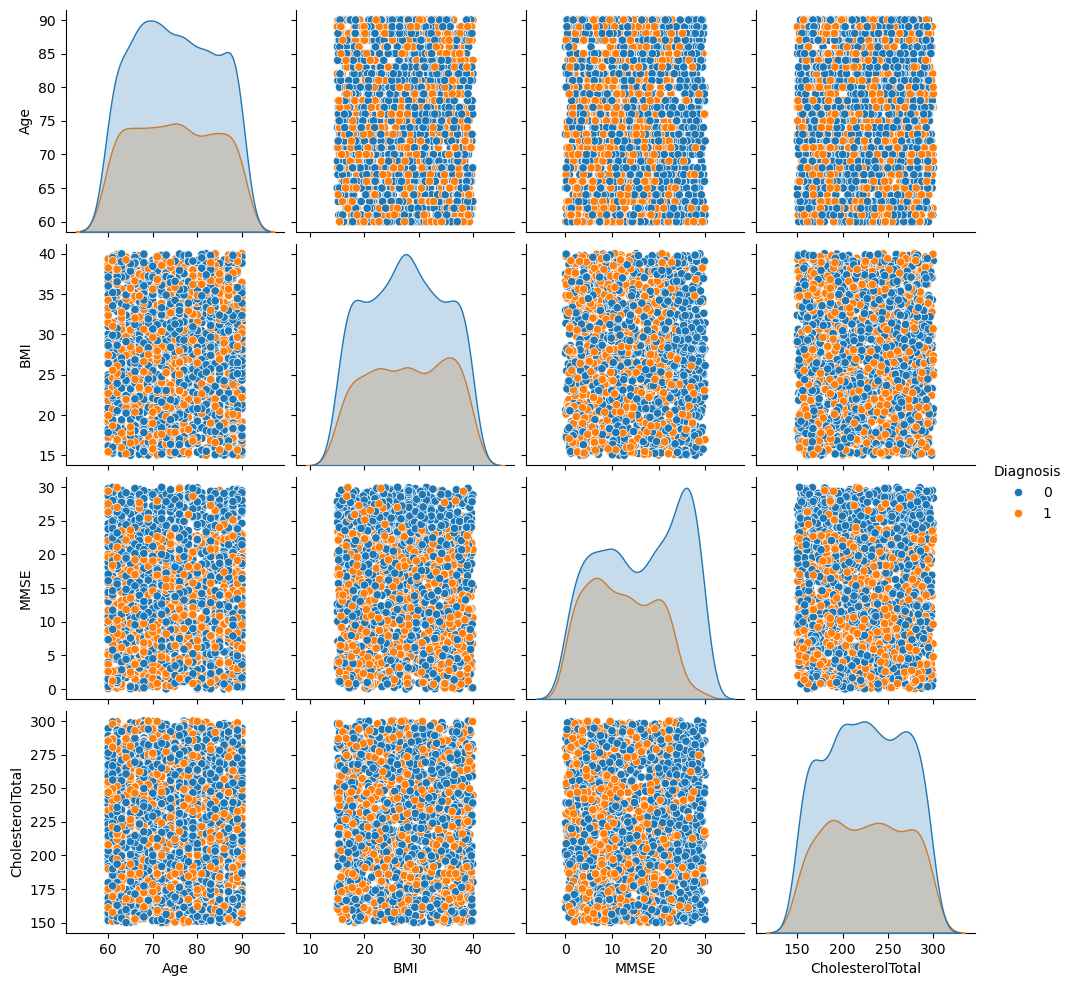

In [194]:
selected_cols = ["Age", "BMI", "MMSE", "CholesterolTotal", "Diagnosis"]

sns.pairplot(df[selected_cols], hue="Diagnosis", diag_kind="kde")
plt.show()

<h3>Model</h3>

<h3>Encoding the Diagnosis Label</h3>

In [198]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Diagnosis"] = le.fit_transform(df["Diagnosis"])


<h3>Feature Matrix (X) and Target Vector (y) + Train/Test Split</h3>

In [206]:
X = df.drop(columns=[ "Diagnosis","DoctorInCharge"]) 
y = df["Diagnosis"]
# train 80% : test 20%
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((1719, 33), (430, 33))

<h3>Model Selection</h3>

<h4>Random Forest Classifier</h4>

In [216]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [220]:

from sklearn.preprocessing import MinMaxScaler

cholesterol_cols = [
    'CholesterolTotal',
    'CholesterolLDL',
    'CholesterolHDL',
    'CholesterolTriglycerides'
]

#scaler = MinMaxScaler()

# تدريب الـ scaler على بيانات التدريب
X_train[cholesterol_cols] = scaler.fit_transform(
    X_train[cholesterol_cols]
)

# تطبيق نفس التحويل على بيانات الاختبار
X_test[cholesterol_cols] = scaler.transform(
    X_test[cholesterol_cols]
)


In [222]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_acc)
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9372093023255814
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       278
           1       0.94      0.88      0.91       152

    accuracy                           0.94       430
   macro avg       0.94      0.92      0.93       430
weighted avg       0.94      0.94      0.94       430



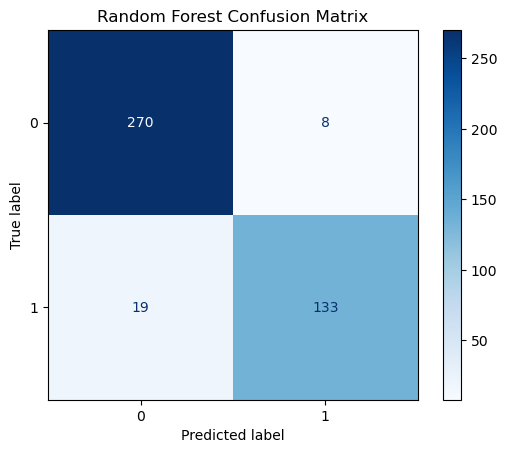

In [224]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap=plt.cm.Blues)  
plt.title("Random Forest Confusion Matrix")
plt.show()


<h1>===================================================</h1>

In [226]:
import joblib

# حفظ الموديل
joblib.dump(rf_model, "alzheimer_model.joblib")

# حفظ الـ scaler
joblib.dump(scaler, "alzheimer_scaler.joblib")

print("تم حفظ الموديل والـ Scaler بنجاح")


تم حفظ الموديل والـ Scaler بنجاح
